# CUSTOMER INTELLIGENCE SYSTEM

In [9]:
# ============================================================
# CUSTOMER INTELLIGENCE SYSTEM
# End-to-End ML Pipeline: Clustering + Classification
# Dataset: Country Data (Kaggle)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             silhouette_score)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## DATA LOADING & UNDERSTANDING

This section focuses on loading the dataset and performing initial checks to understand its structure, content, and basic statistics. 

In [11]:
df = pd.read_csv('Country-data.csv')
print("Shape:", df.shape)
print(f"   {df.shape[0]} countries | {df.shape[1]} columns\n")
print("Columns:", df.columns.tolist())
print("\n First 5 Rows:")
print(df.head())


Shape: (167, 10)
   167 countries | 10 columns

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

 First 5 Rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [12]:
print("Data Types & Non-Null Counts:\n")
df.info()

Data Types & Non-Null Counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## FEATURE UNDERSTANDING
we examine the meaning and context of each feature in the dataset, providing a reference for better interpretation.

In [6]:
print("Missing Values:\n")
missing = df.isnull().sum()
print(missing)

Missing Values:

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [7]:
print("Statistical Summary:\n")
df.describe().T.round(2)

Statistical Summary:



,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [8]:
# Data understanding

feature_desc = {
    'country'   : 'Name of the country',
    'child_mort': 'Child mortality rate per 1000 live births',
    'exports'   : 'Exports as % of GDP',
    'health'    : 'Health spending as % of GDP',
    'imports'   : 'Imports as % of GDP',
    'income'    : 'Net income per person (USD)',
    'inflation' : 'Inflation rate (%)',
    'life_expec': 'Life expectancy (years)',
    'total_fer' : 'Total fertility rate (children per woman)',
    'gdpp'      : 'GDP per capita (USD)'
}

desc_df = pd.DataFrame(list(feature_desc.items()),
                        columns=['Feature', 'Description'])
print("Feature Reference:\n")
print(desc_df.to_string(index=False))

Feature Reference:

   Feature                               Description
   country                       Name of the country
child_mort Child mortality rate per 1000 live births
   exports                       Exports as % of GDP
    health               Health spending as % of GDP
   imports                       Imports as % of GDP
    income               Net income per person (USD)
 inflation                        Inflation rate (%)
life_expec                   Life expectancy (years)
 total_fer Total fertility rate (children per woman)
      gdpp                      GDP per capita (USD)


## EXPLORATORY DATA ANALYSIS (EDA)


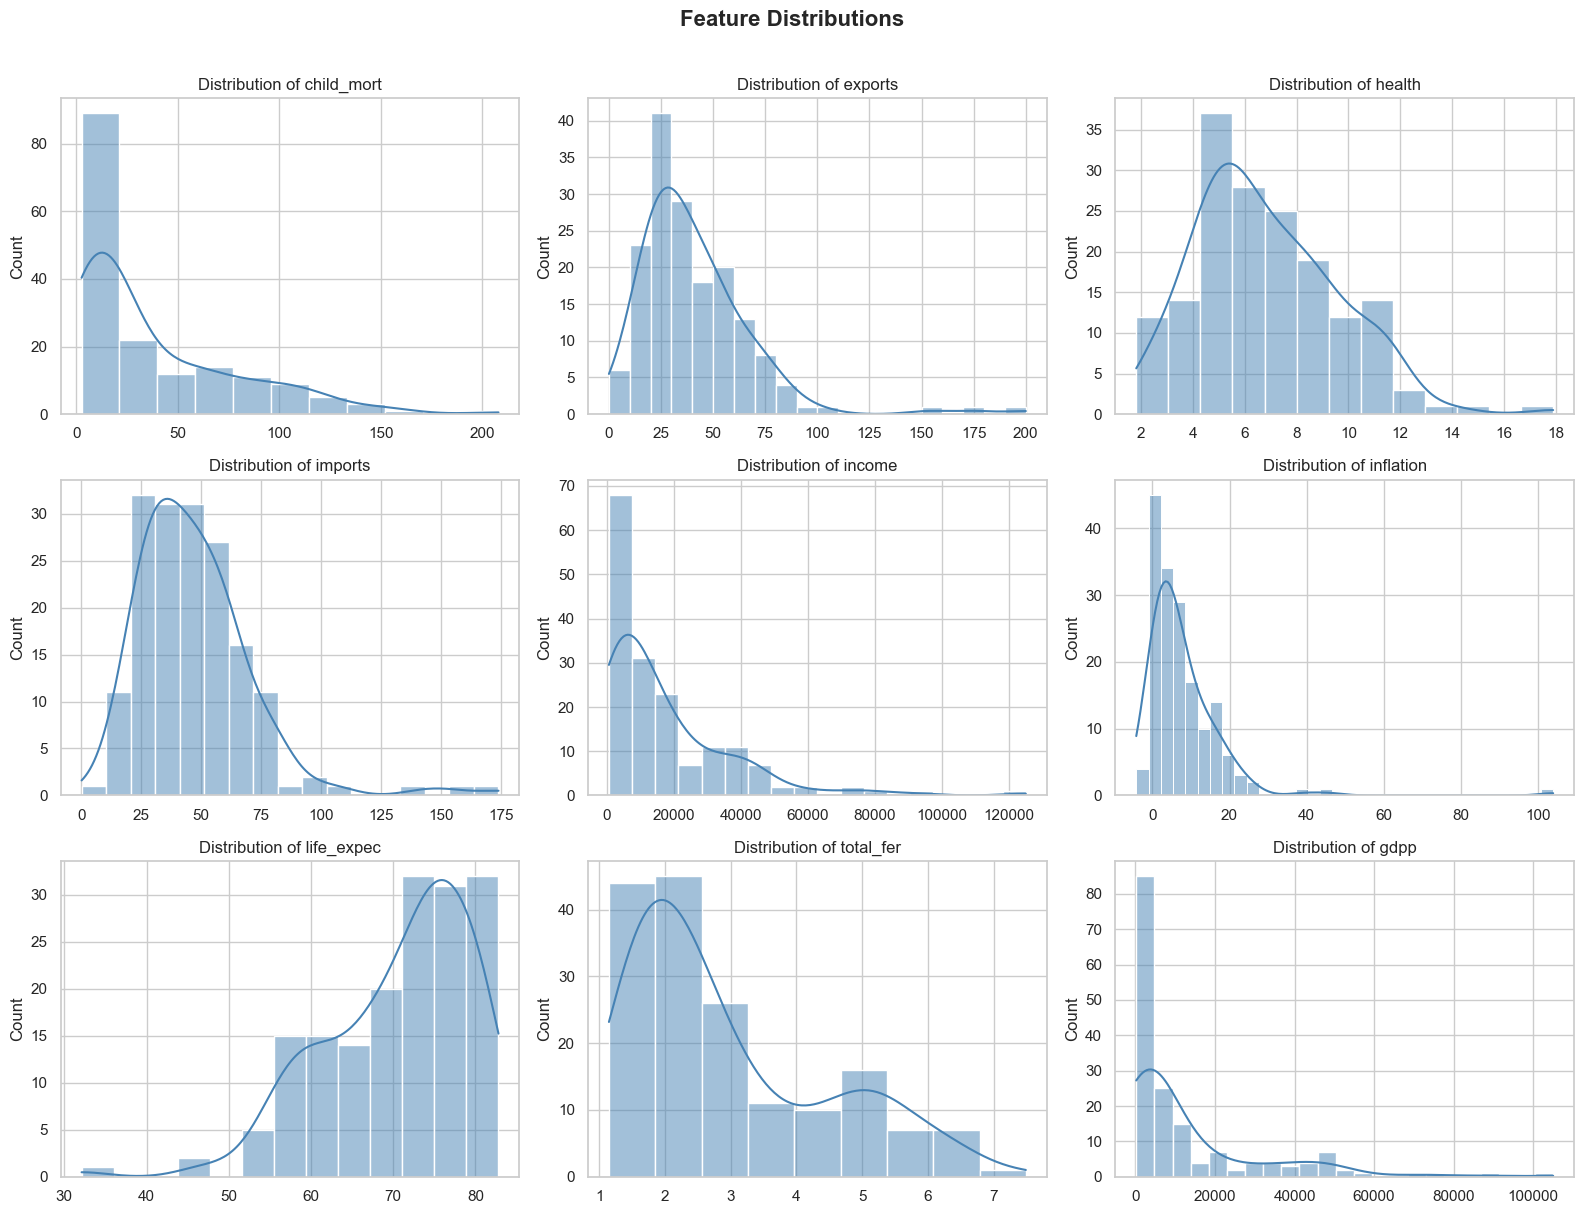

In [ ]:
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Outlier Detection  

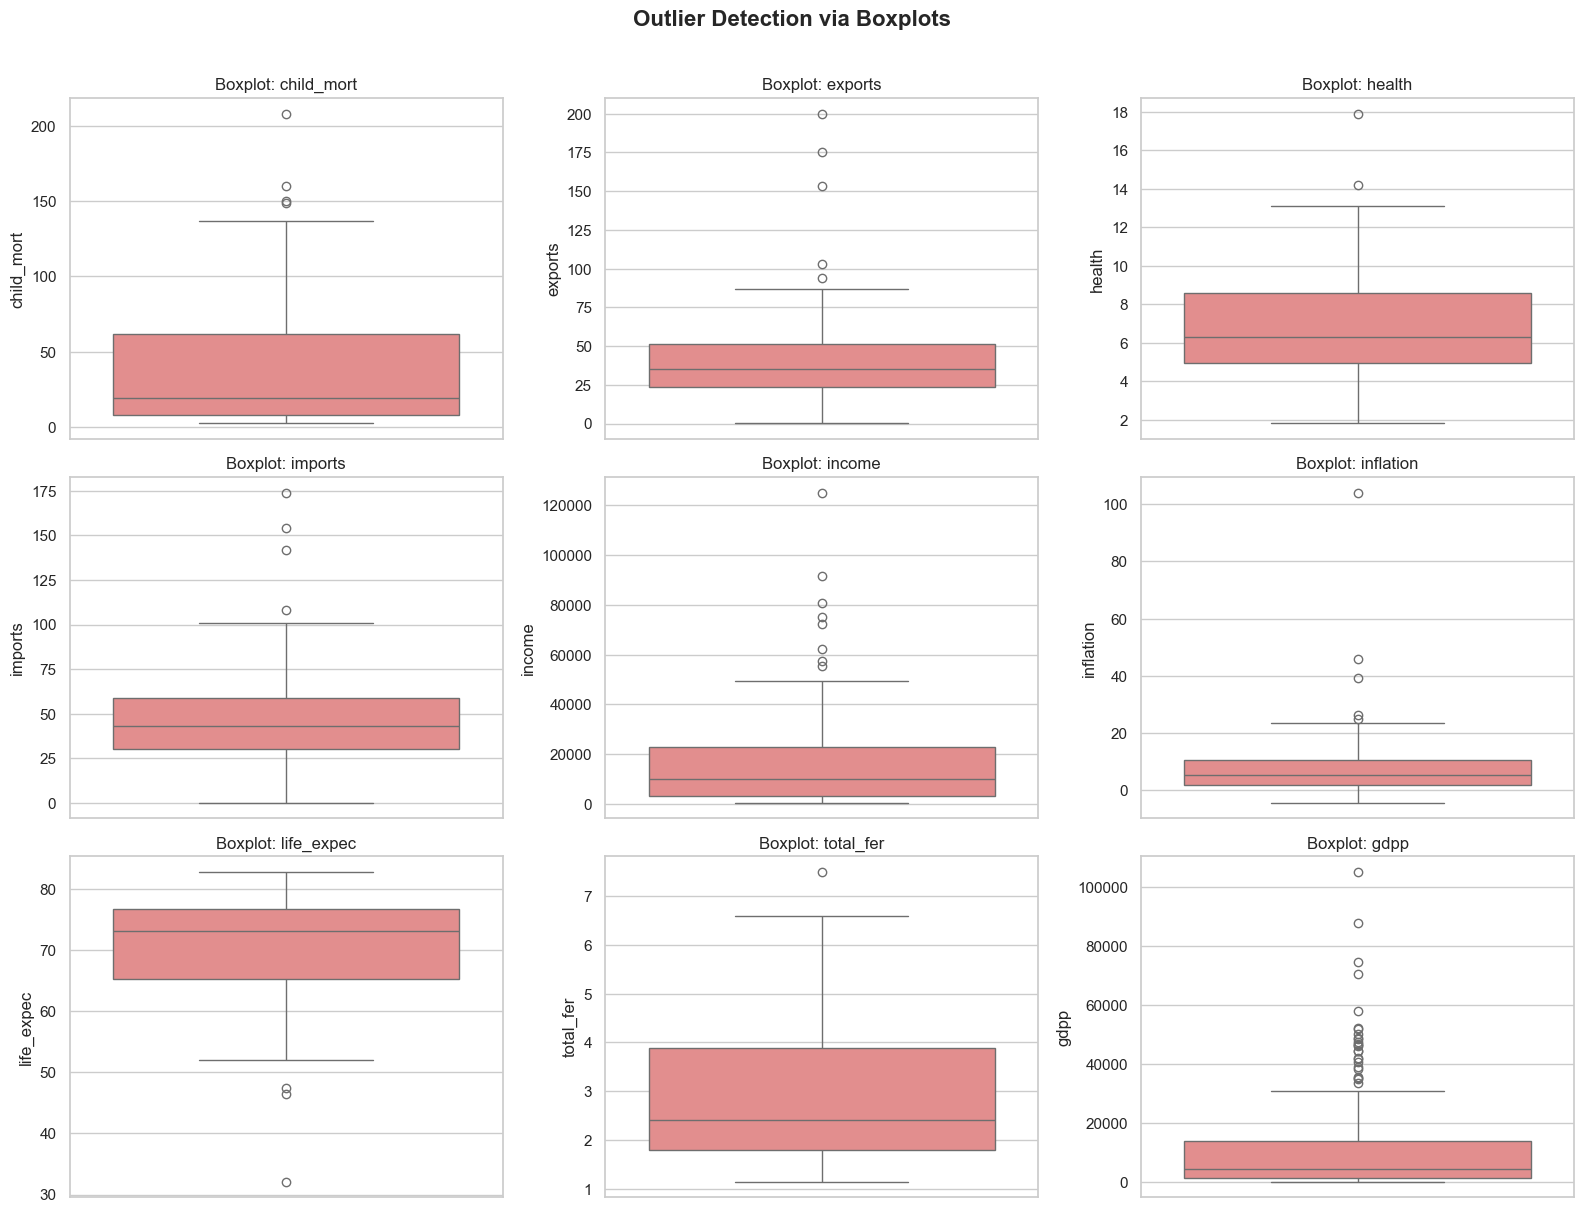

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Outlier Detection via Boxplots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Correaltion Analysis

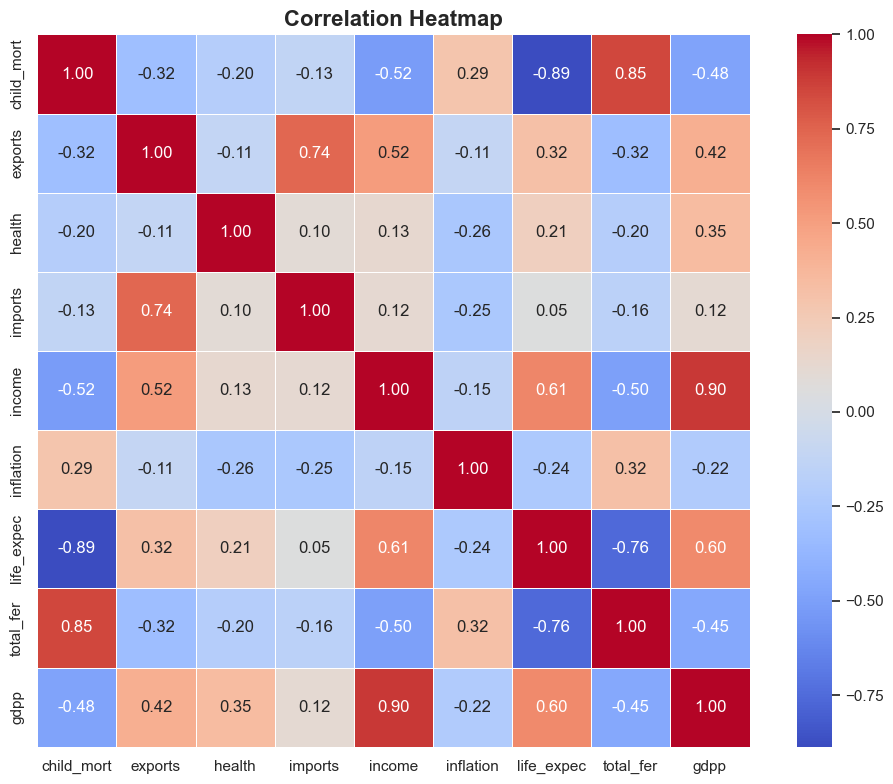


 Key Observations:
  • child_mort & life_expec: strong negative correlation
  • child_mort & total_fer:  strong positive correlation
  • income & gdpp:           strong positive correlation


In [15]:
plt.figure(figsize=(10, 8))
corr = df[features].corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Key Observations:")
print("  • child_mort & life_expec: strong negative correlation")
print("  • child_mort & total_fer:  strong positive correlation")
print("  • income & gdpp:           strong positive correlation")

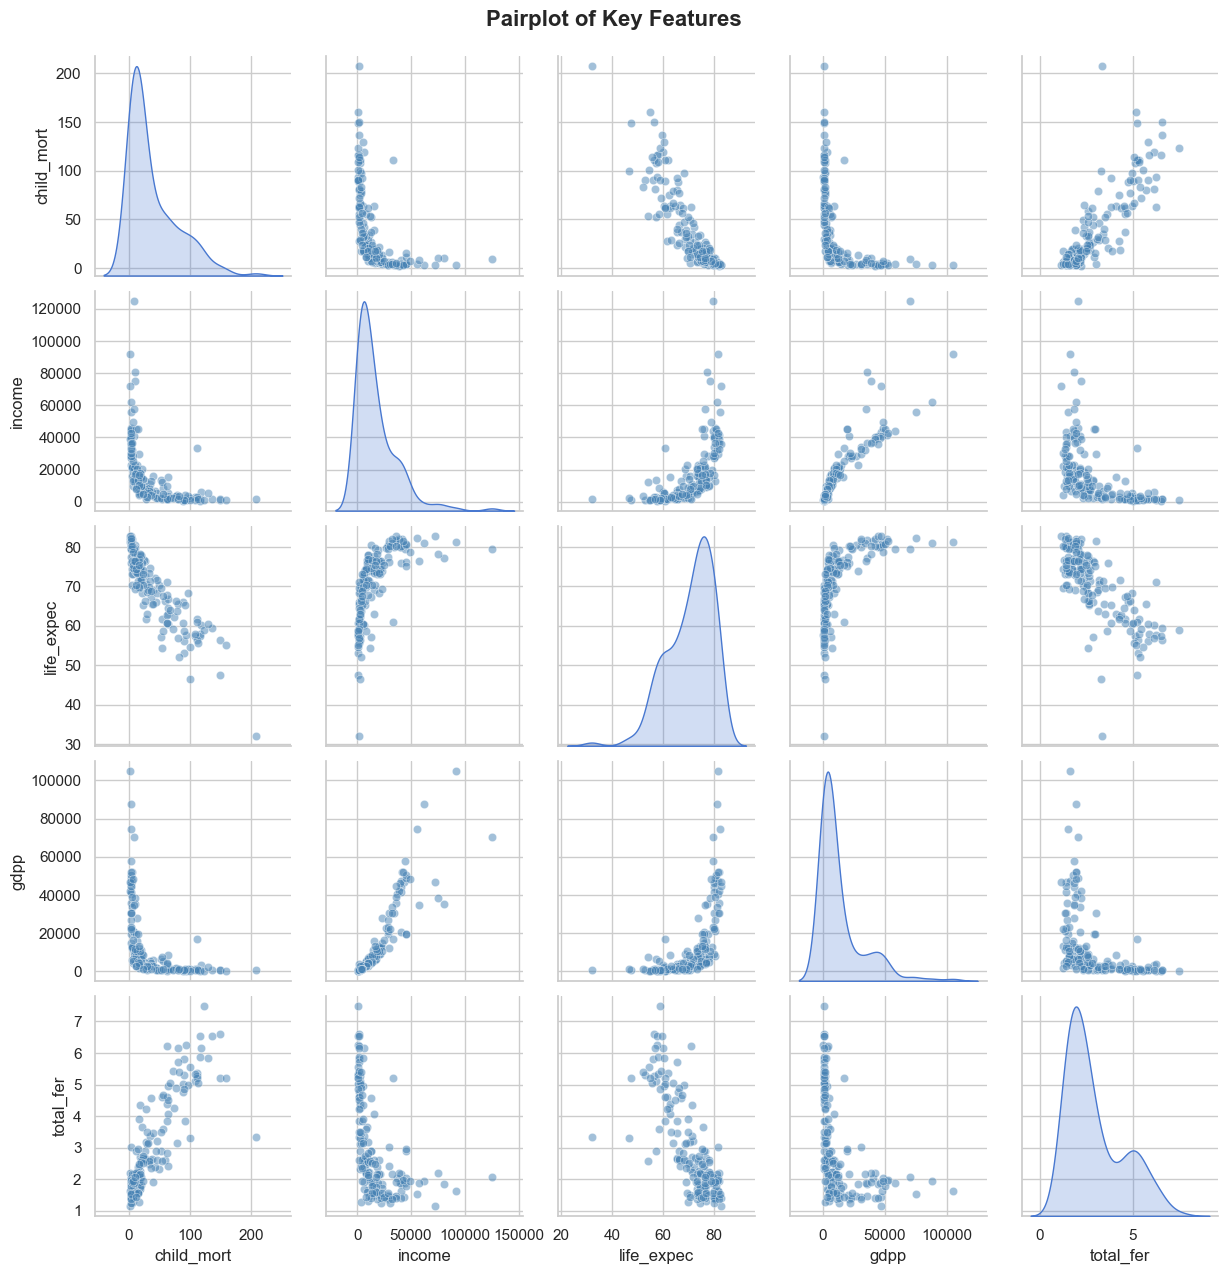

In [16]:
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
sns.pairplot(df[key_features], diag_kind='kde',
             plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pairplot of Key Features', fontsize=16,
             fontweight='bold', y=1.02)
plt.show()

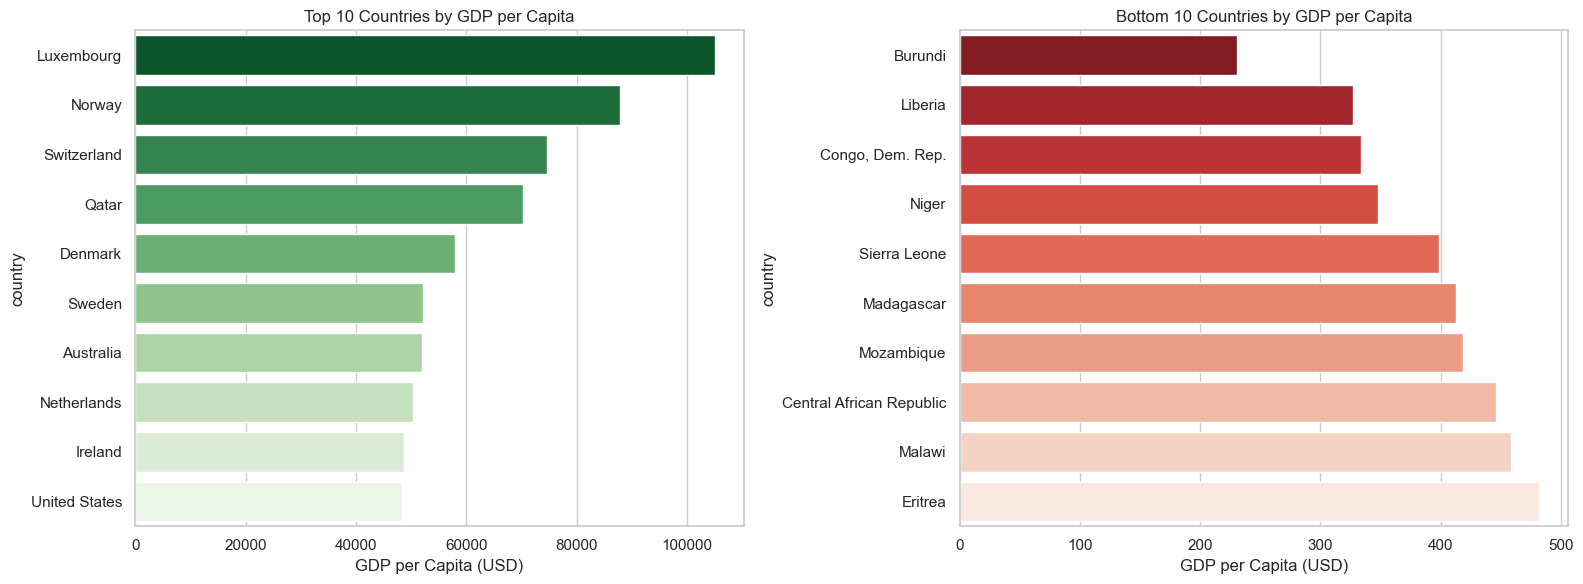

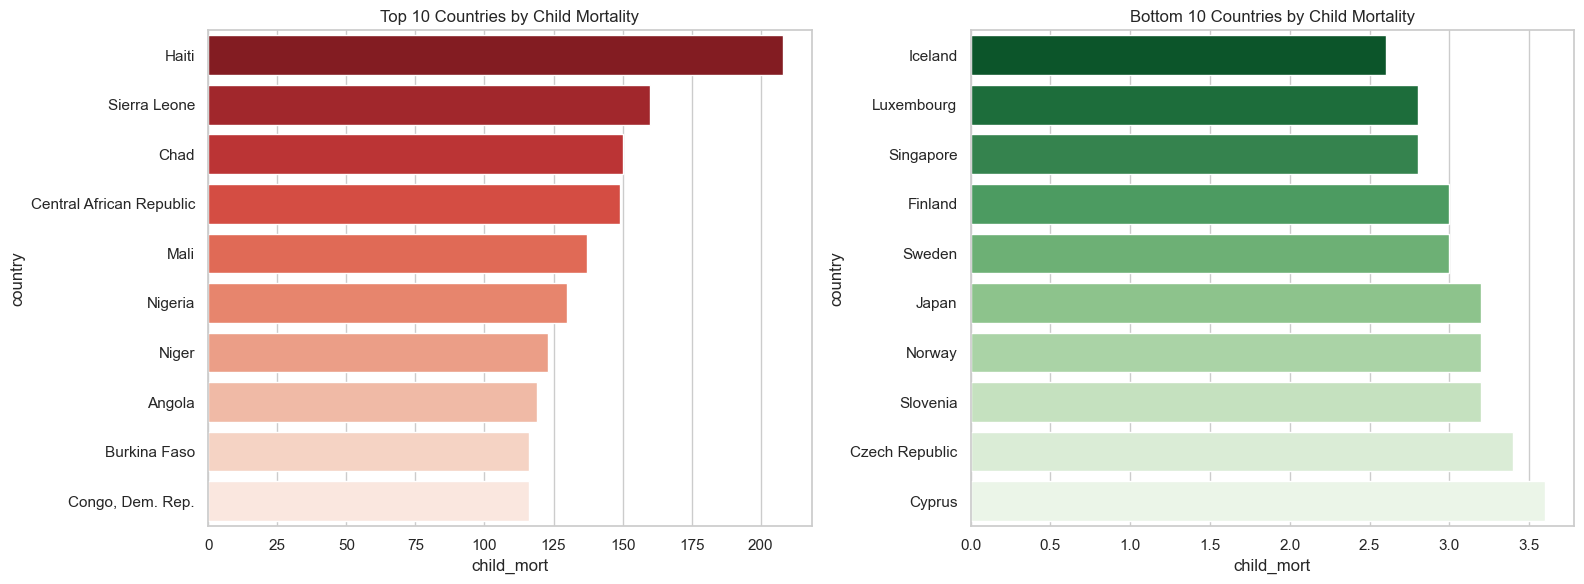

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Top 10 by GDP
top10 = df.nlargest(10, 'gdpp')
sns.barplot(data=top10, x='gdpp', y='country', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Countries by GDP per Capita')
axes[0].set_xlabel('GDP per Capita (USD)')
# Bottom 10 by GDP
bottom10 = df.nsmallest(10, 'gdpp')
sns.barplot(data=bottom10, x='gdpp', y='country', ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 10 Countries by GDP per Capita')
axes[1].set_xlabel('GDP per Capita (USD)')
plt.tight_layout()
plt.show()
# Child Mortality
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top10_cm = df.nlargest(10, 'child_mort')
sns.barplot(data=top10_cm, x='child_mort', y='country', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Countries by Child Mortality')
bottom10_cm = df.nsmallest(10, 'child_mort')
sns.barplot(data=bottom10_cm, x='child_mort', y='country', ax=axes[1], palette='Greens_r')
axes[1].set_title('Bottom 10 Countries by Child Mortality')
plt.tight_layout()
plt.show()

## outlier handling

In [18]:
#preprocessing through quartile method
df_clean = df.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)
print("Outliers capped using IQR method")
print(f"Shape remains: {df_clean.shape}")

Outliers capped using IQR method
Shape remains: (167, 10)


In [19]:
#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Features scaled using StandardScaler")
print("\nScaled Data Sample:")
X_scaled_df.head()

Features scaled using StandardScaler

Scaled Data Sample:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
3,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
4,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686


## K-MEANS CLUSTERING
using methods like the Elbow and Silhouette scores to determine the optimal number of clusters.

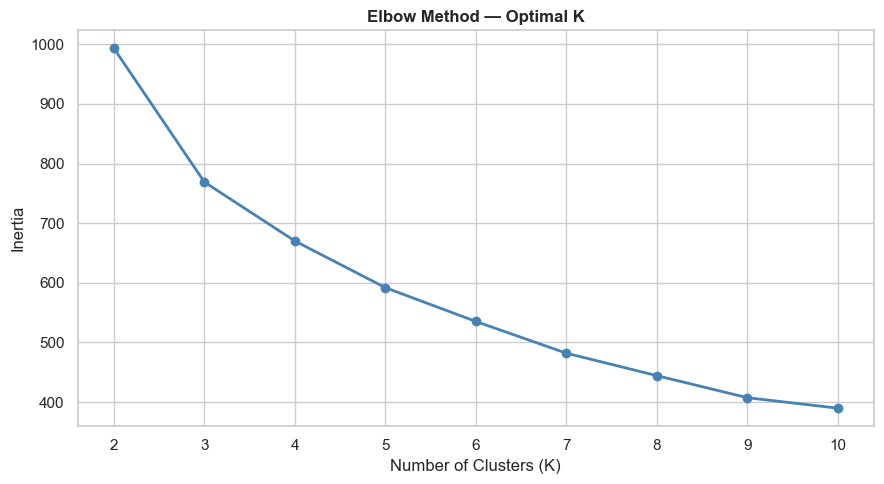

In [20]:
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K', fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

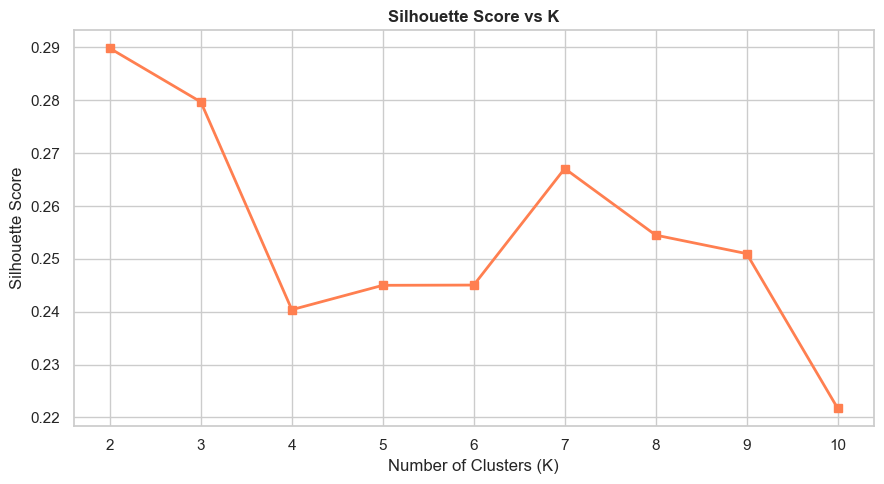

Best K by Silhouette Score: 2
Silhouette Score: 0.2898


In [21]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
plt.figure(figsize=(9, 5))
plt.plot(K_range, sil_scores, marker='s', color='coral', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K', fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.show()
best_k = K_range[np.argmax(sil_scores)]
print(f"Best K by Silhouette Score: {best_k}")
print(f"Silhouette Score: {max(sil_scores):.4f}")

In [22]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
print(f"K-Means trained with K={best_k}")
print("\nCluster Distribution:")
print(df_clean['KMeans_Cluster'].value_counts().sort_index())

K-Means trained with K=2

Cluster Distribution:
KMeans_Cluster
0    98
1    69
Name: count, dtype: int64


## PCA VISUALIZATION

This section uses Principal Component Analysis (PCA) to reduce the dimensionality of the data and visualize the K-Means clusters in a 2D space.

PCA Explained Variance: 65.35%


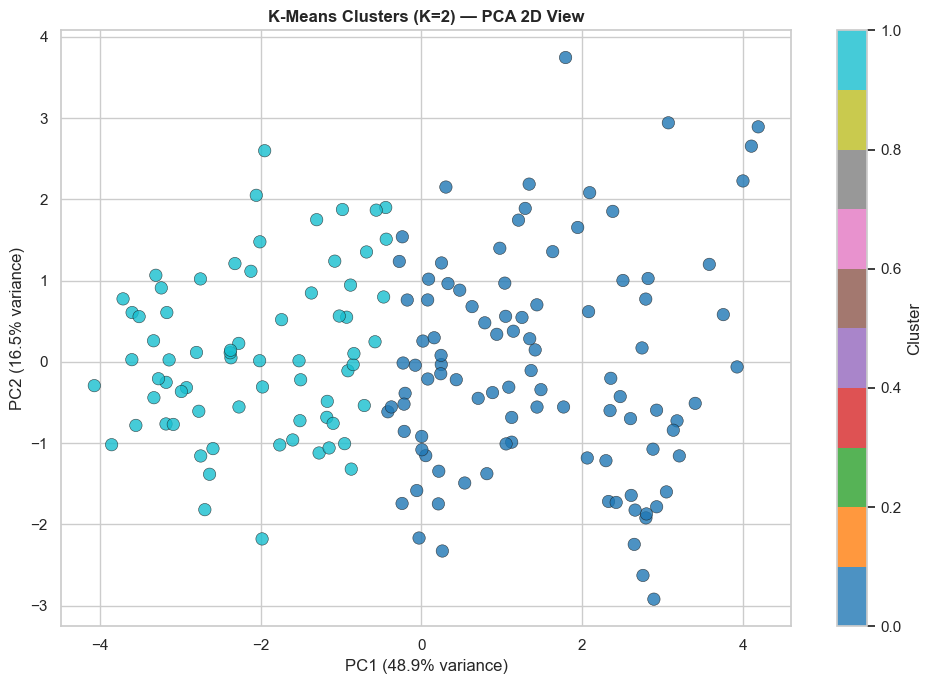

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA Explained Variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_clean['KMeans_Cluster'],
                      cmap='tab10', s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (K={best_k}) — PCA 2D View', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

## DBSCAN CLUSTERING
DBSCAN is a density-based clustering algorithm, to identify clusters of varying shapes and detect noise points.

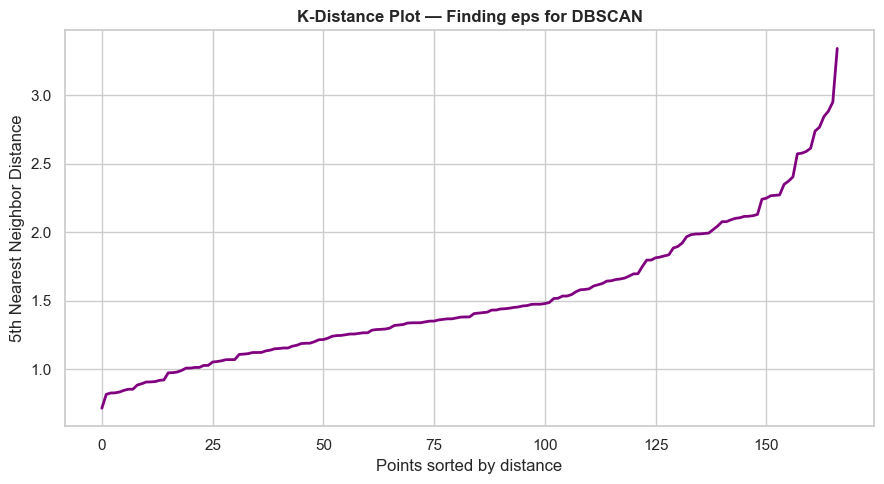

Look for the 'elbow' point — that value is your eps


In [24]:
# K-distance plot to find eps
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])
plt.figure(figsize=(9, 5))
plt.plot(distances, color='purple', linewidth=2)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot — Finding eps for DBSCAN', fontweight='bold')
plt.tight_layout()
plt.show()
print("Look for the 'elbow' point — that value is your eps")

In [25]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - (1 if -1 in df_clean['DBSCAN_Cluster'].values else 0)
n_noise = (df_clean['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN Results:")
print(f"Clusters Found : {n_clusters}")
print(f"Noise Points   : {n_noise}")
print("\nCluster Distribution:")
print(df_clean['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Results:
Clusters Found : 1
Noise Points   : 1

Cluster Distribution:
DBSCAN_Cluster
-1      1
 0    166
Name: count, dtype: int64


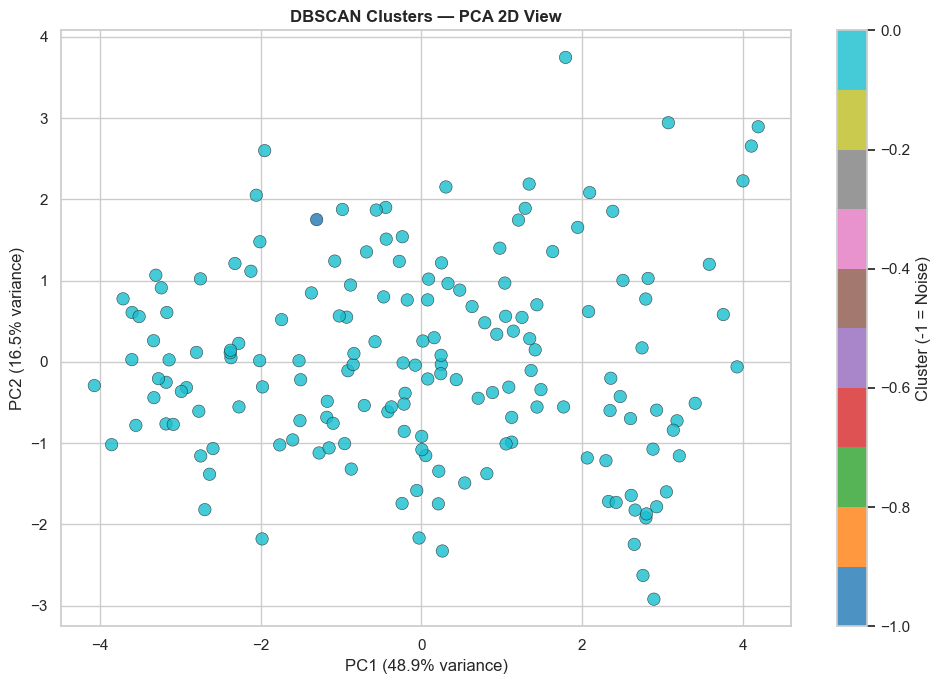

In [26]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_clean['DBSCAN_Cluster'],
                      cmap='tab10', s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.title('DBSCAN Clusters — PCA 2D View', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

## Clustering Model Comparision

In [27]:
# DBSCAN silhouette (exclude noise)
mask = df_clean['DBSCAN_Cluster'] != -1
if mask.sum() > 1 and len(df_clean.loc[mask, 'DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[mask], df_clean.loc[mask, 'DBSCAN_Cluster'])
else:
    db_sil = None

km_sil = silhouette_score(X_scaled, df_clean['KMeans_Cluster'])

comparison = pd.DataFrame({
    'Method'           : ['K-Means', 'DBSCAN'],
    'Clusters Found'   : [best_k, n_clusters],
    'Silhouette Score' : [round(km_sil, 4), round(db_sil, 4) if db_sil else 'N/A'],
    'Noise Points'     : ['N/A', n_noise]
})

print("Clustering Comparison:\n")
print(comparison.to_string(index=False))

Clustering Comparison:

 Method  Clusters Found Silhouette Score Noise Points
K-Means               2           0.2898          N/A
 DBSCAN               1              N/A            1


## COUNTRY-LEVEL SEGMENTATION INSIGHTS

This section focuses on interpreting the derived clusters and assigning meaningful labels to understand the socio-economic segments of countries.

In [28]:
cluster_profile = df_clean.groupby('KMeans_Cluster')[features].mean().round(2)
print("Cluster Profiles (Mean Values):\n")
cluster_profile

Cluster Profiles (Mean Values):



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,12.17,46.23,7.32,47.6,24111.02,5.11,76.52,1.94,16236.02
1,73.95,30.04,6.04,43.4,4290.19,9.85,62.35,4.37,1993.25


## CLUSTERS → CLASSIFICATION LABELS

Here, we transform the identified clusters into target labels for supervised classification, enabling the prediction of country segments.

In [29]:
# Assign meaningful names based on profile
cluster_names = {}
for cluster in range(best_k):
    gdpp  = cluster_profile.loc[cluster, 'gdpp']
    cm    = cluster_profile.loc[cluster, 'child_mort']
    le    = cluster_profile.loc[cluster, 'life_expec']

    if gdpp > 15000 and le > 70 and cm < 30:
        cluster_names[cluster] = 'Developed'
    elif gdpp > 5000:
        cluster_names[cluster] = 'Developing'
    else:
        cluster_names[cluster] = 'Underdeveloped'

df_clean['Segment'] = df_clean['KMeans_Cluster'].map(cluster_names)

print("Cluster Labels:\n")
for k, v in cluster_names.items():
    print(f"   Cluster {k} → {v}")

print("\nSegment Distribution:")
print(df_clean['Segment'].value_counts())

Cluster Labels:

   Cluster 0 → Developed
   Cluster 1 → Underdeveloped

Segment Distribution:
Segment
Developed         98
Underdeveloped    69
Name: count, dtype: int64


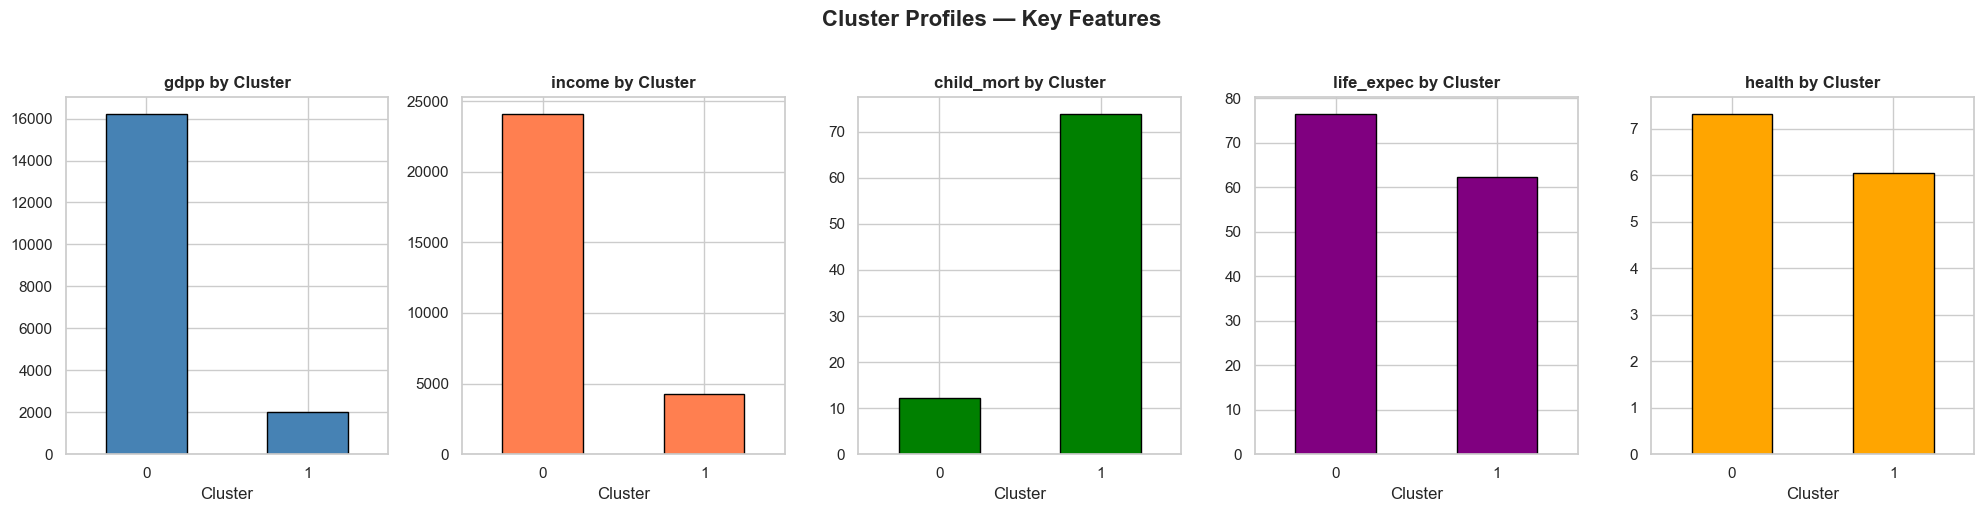

In [30]:
key_cols = ['gdpp', 'income', 'child_mort', 'life_expec', 'health']
colors   = ['steelblue', 'coral', 'green', 'purple', 'orange']

fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 5))

for i, col in enumerate(key_cols):
    cluster_profile[col].plot(kind='bar', ax=axes[i],
                               color=colors[i], edgecolor='black')
    axes[i].set_title(f'{col} by Cluster', fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Cluster Profiles — Key Features', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
print("Sample Countries per Segment:\n")
for segment in df_clean['Segment'].unique():
    countries = df_clean[df_clean['Segment'] == segment]['country'].values[:8]
    print(f"  {segment}: {', '.join(countries)}")
    print()

Sample Countries per Segment:

  Underdeveloped: Afghanistan, Angola, Bangladesh, Benin, Bolivia, Botswana, Burkina Faso, Burundi

  Developed: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan



In [33]:
# CLUSTERS → CLASSIFICATION LABELS
le = LabelEncoder()
df_clean['Target'] = le.fit_transform(df_clean['Segment'])
print("Encoded Labels:")
for i, cls in enumerate(le.classes_):
    print(f"   {i} → {cls}")
print(f"\nTarget Distribution:\n{df_clean['Target'].value_counts()}")

Encoded Labels:
   0 → Developed
   1 → Underdeveloped

Target Distribution:
Target
0    98
1    69
Name: count, dtype: int64


## CLASSIFICATION MODELS
In this section we deal with training and evaluating various classification models, such as Random Forest and XGBoost, to predict country segments.

In [34]:
# splitting data
X = X_scaled
y = df_clean['Target'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train/Test Split:A")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")

Train/Test Split:A
   Training samples : 133
   Testing samples  : 34


In [48]:
#RandonForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Results:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   F1 Score : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Results:
   Accuracy : 0.8824
   F1 Score : 0.8832

Classification Report:
                precision    recall  f1-score   support

     Developed       0.94      0.85      0.89        20
Underdeveloped       0.81      0.93      0.87        14

      accuracy                           0.88        34
     macro avg       0.88      0.89      0.88        34
  weighted avg       0.89      0.88      0.88        34



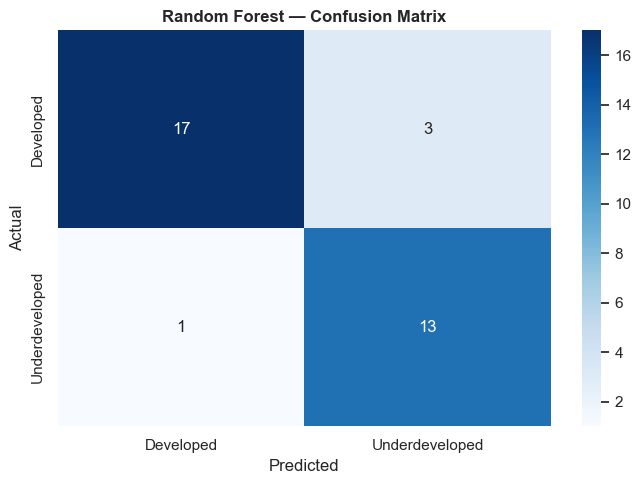

In [49]:
plt.figure(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

feature importance

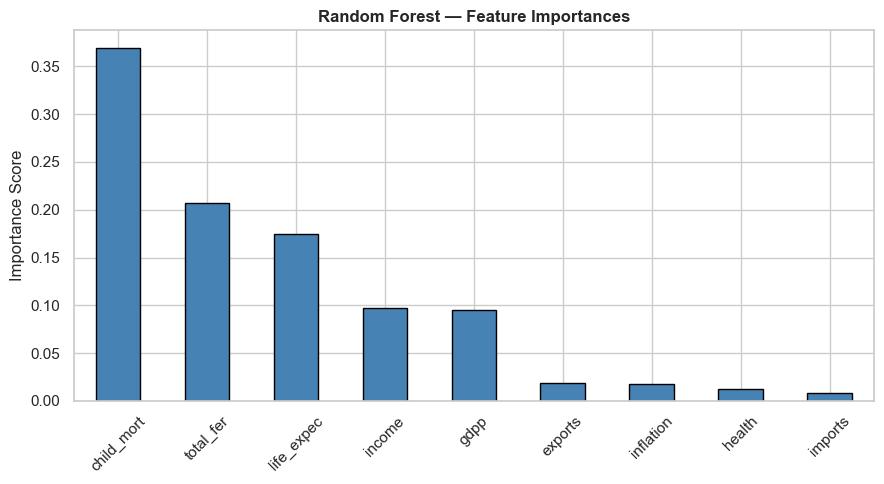

In [50]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# XGboost classifier
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"   F1 Score : {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost Results:
   Accuracy : 0.9118
   F1 Score : 0.9125

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.85      0.92        20
Underdeveloped       0.82      1.00      0.90        14

      accuracy                           0.91        34
     macro avg       0.91      0.93      0.91        34
  weighted avg       0.93      0.91      0.91        34



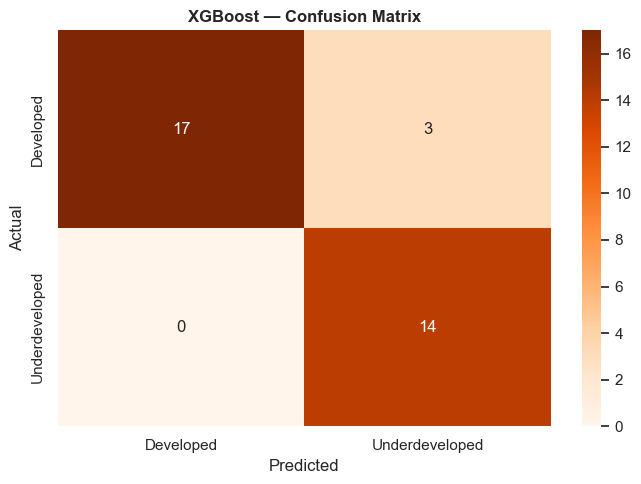

In [52]:
plt.figure(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Hyper Parameter Tuning

In [53]:
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth'    : [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                        rf_params, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print(f"   Best CV F1     : {rf_grid.best_score_:.4f}")

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   Best CV F1     : 0.9852


In [54]:
xgb_params = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False,
                                        eval_metric='mlogloss'),
                          xgb_params, cv=5, scoring='f1_weighted', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("Best XGB Params:", xgb_grid.best_params_)
print(f"   Best CV F1     : {xgb_grid.best_score_:.4f}")

Best XGB Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
   Best CV F1     : 0.9700


In [55]:
best_rf  = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
y_pred_rf_tuned  = best_rf.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)
print("Tuned RF  Accuracy:", round(accuracy_score(y_test, y_pred_rf_tuned), 4))
print("Tuned XGB Accuracy:", round(accuracy_score(y_test, y_pred_xgb_tuned), 4))

Tuned RF  Accuracy: 0.8824
Tuned XGB Accuracy: 0.9118


In [56]:
# ENSEMBLE MODEL
# VOTING CLASSIFIER
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
print("Ensemble (Voting) Results:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"   F1 Score : {f1_score(y_test, y_pred_ens, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

Ensemble (Voting) Results:
   Accuracy : 0.8824
   F1 Score : 0.8832

Classification Report:
                precision    recall  f1-score   support

     Developed       0.94      0.85      0.89        20
Underdeveloped       0.81      0.93      0.87        14

      accuracy                           0.88        34
     macro avg       0.88      0.89      0.88        34
  weighted avg       0.89      0.88      0.88        34



## MODEL COMPARISON
by highlighting models accuracy and f1-score we compare all models

📊 Model Comparison:

        Model  Accuracy  F1 Score
Random Forest    0.8824    0.8832
      XGBoost    0.9118    0.9125
     Tuned RF    0.8824    0.8832
Tuned XGBoost    0.9118    0.9125
     Ensemble    0.8824    0.8832


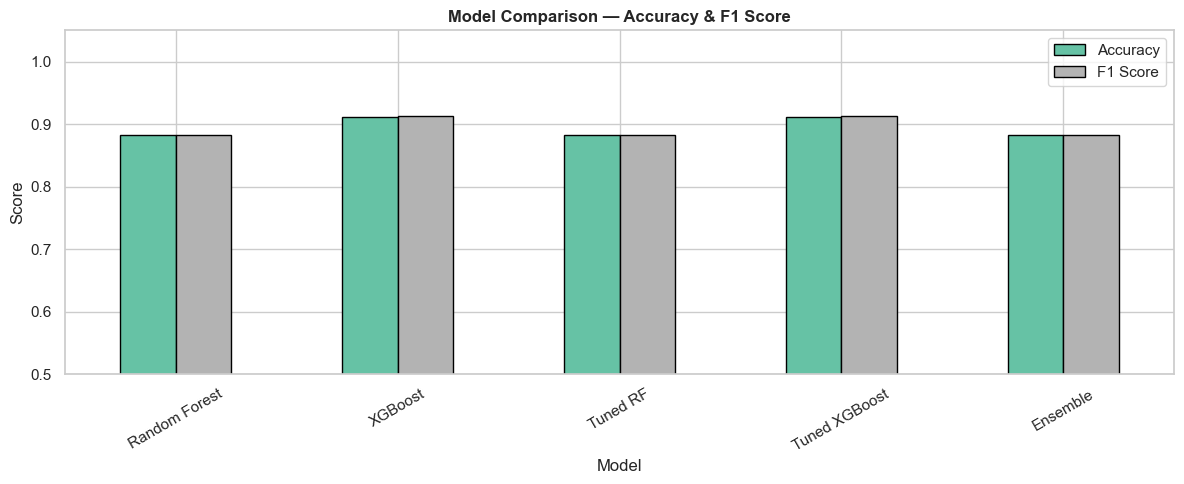

In [57]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Tuned RF', 'Tuned XGBoost', 'Ensemble'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned),
        accuracy_score(y_test, y_pred_ens)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf,       average='weighted'),
        f1_score(y_test, y_pred_xgb,      average='weighted'),
        f1_score(y_test, y_pred_rf_tuned, average='weighted'),
        f1_score(y_test, y_pred_xgb_tuned,average='weighted'),
        f1_score(y_test, y_pred_ens,      average='weighted')
    ]
}).round(4)
print("📊 Model Comparison:\n")
print(results.to_string(index=False))
# Bar chart
results.set_index('Model')[['Accuracy', 'F1 Score']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black', colormap='Set2')
plt.title('Model Comparison — Accuracy & F1 Score', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

## CONCLUSION

This is final phase here we summarizes the key findings from the entire analysis, including clustering insights, classification performance, and potential future work.

In [61]:
best_model_row = results.loc[results['F1 Score'].idxmax()]
print("*" * 55)
print("         CUSTOMER INTELLIGENCE SYSTEM — SUMMARY")
print("*" * 55)
print(f"""
--> DATASET
   • 167 countries | 9 features (socio-economic indicators)
   
--> CLUSTERING
   • K-Means (K={best_k}) — Silhouette Score: {km_sil:.4f}
   • DBSCAN  — Clusters: {n_clusters} | Noise Points: {n_noise}
   • Best Method: K-Means

--> SEGMENTS IDENTIFIED
   • Developed      -> High GDP, High Life Expectancy, Low Child Mortality
   • Developing     -> Mid-range across all indicators
   • Underdeveloped -> Low GDP, Low Life Expectancy, High Child Mortality

--> CLASSIFICATION
   • Best Model : {best_model_row['Model']}
   • Accuracy   : {best_model_row['Accuracy']:.4f}
   • F1 Score   : {best_model_row['F1 Score']:.4f}

--> KEY INSIGHTS
   • GDP per capita & income are strongest cluster separators
   • child_mort & life_expec are inversely correlated
   • Ensemble model provides most robust predictions

--> FUTURE SCOPE
   • Add time-series data for trend analysis
   • Deploy as interactive dashboard (Streamlit)
   • Apply UMAP for better dimensionality reduction
""")
print("*" * 55)

*******************************************************
         CUSTOMER INTELLIGENCE SYSTEM — SUMMARY
*******************************************************

--> DATASET
   • 167 countries | 9 features (socio-economic indicators)
   
--> CLUSTERING
   • K-Means (K=2) — Silhouette Score: 0.2898
   • DBSCAN  — Clusters: 1 | Noise Points: 1
   • Best Method: K-Means

--> SEGMENTS IDENTIFIED
   • Developed      -> High GDP, High Life Expectancy, Low Child Mortality
   • Developing     -> Mid-range across all indicators
   • Underdeveloped -> Low GDP, Low Life Expectancy, High Child Mortality

--> CLASSIFICATION
   • Best Model : XGBoost
   • Accuracy   : 0.9118
   • F1 Score   : 0.9125

--> KEY INSIGHTS
   • GDP per capita & income are strongest cluster separators
   • child_mort & life_expec are inversely correlated
   • Ensemble model provides most robust predictions

--> FUTURE SCOPE
   • Add time-series data for trend analysis
   • Deploy as interactive dashboard (Streamlit)
   • Ap